# WEEK 1: 光学衛星の基礎 — 演習ノート
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/exercises/week1_exercise.ipynb)

> **Private リポジトリの注意:**
> このリポジトリは Private 設定のため、上のバッジから直接開けない場合があります。
> その場合は以下の手順で開いてください：
>
> 1. [Google Colab](https://colab.research.google.com/) にアクセス
> 2. 「ファイル」→「ノートブックを開く」→「GitHub」タブ
> 3. 「プライベート リポジトリを含める」にチェックを入れる
> 4. 初回はGitHub認証が求められるので許可する
> 5. リポジトリ `astrocamp-2026-siaPpts/astrocamp-2026-sia` を選択し、該当ノートブックを開く

このノートブックは **演習用** です。コードの一部が空欄（`???`）になっています。
自分で調べて埋めながら、衛星データ解析の基礎を身につけてください。

### 進め方
1. `???` と書かれた箇所を適切なコードに書き換える
2. わからない場合は、各セクションの下にある **ヒント** を読む
3. それでもわからない場合は、`_private/01_kogaku.ipynb` を正解として参照してよい
4. **写経ではなく「なぜこれが必要か」を考えながら進めること**

### 学習目標
- GEE で衛星画像を検索・取得できる
- NDVI を計算し、その物理的意味を説明できる
- 光学センサの限界を具体例で示せる
- チャレンジ課題のうち **最低2問** に挑戦する

### 🕵️ データを探索しよう（推奨）

コードを実行する前に、[Copernicus Browser](https://dataspace.copernicus.eu/browser/) や [VEGA](https://vega.naro.go.jp/) で
福島県相馬市周辺の2024年の衛星画像を眺めてみよう。

**チェックポイント:**
- □ 雲の少ない画像がどの月に多いか確認した
- □ 田んぼに水が入っている時期と収穫後の時期で見え方が違うことを確認した
- □ 「この日付のデータでNDVIを計算してみたい」と思える時期をメモした

> 💡 この事前探索が、あとでGEEのパラメータを自分で調整する時の判断材料になる。
> **「与えられたコードを実行するだけ」ではなく、自分で「どのデータを使うか」を選ぶ習慣をつけよう。**


In [1]:
# 必要なライブラリのインストール（Colab 環境の場合）
!pip install geemap earthengine-api


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
print(sys.executable)

import ee
print(ee.__file__)

c:\Users\haous\OneDrive - 電気通信大学\バックアップ\Windows\date\Astrocamp\.venv\Scripts\python.exe
c:\Users\haous\OneDrive - 電気通信大学\バックアップ\Windows\date\Astrocamp\.venv\Lib\site-packages\ee\__init__.py


In [3]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from getpass import getpass

# ── 実行環境の判定 ──
_IN_COLAB = 'google.colab' in sys.modules
print(f'実行環境: {"Google Colab" if _IN_COLAB else "VSCode / ローカル"}')

# ── matplotlib 日本語フォント設定 ──
import matplotlib.font_manager as _fm
import platform
if _IN_COLAB:
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)
    _fm._load_fontmanager(try_read_cache=False)
_system = platform.system()
_jp_candidates = {
    'Darwin': ['Hiragino Sans', 'AppleGothic'],
    'Windows': ['Yu Gothic', 'MS Gothic'],
}.get(_system, ['Noto Sans CJK JP', 'IPAexGothic'])
_found = [f for f in _jp_candidates if f in [x.name for x in _fm.fontManager.ttflist]]
if _found:
    plt.rcParams['font.sans-serif'] = _found
else:
    _alt = sorted(set(x.name for x in _fm.fontManager.ttflist
                       if any(c in x.name for c in ['Noto', 'IPA', 'Gothic', 'Yu', 'Hiragino'])))
    if _alt:
        plt.rcParams['font.sans-serif'] = _alt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# ── GEE 認証 ──
GEE_PROJECT = os.environ.get('GEE_PROJECT')
if not GEE_PROJECT:
    GEE_PROJECT = getpass('GEE プロジェクトIDを入力してください (例: ee-yourproject): ')
print(f'GEE project: {GEE_PROJECT}')
ee.Authenticate()
print('GEE 初期化中...')
try:
    ee.Initialize(project=GEE_PROJECT)
    print('GEE 初期化成功')
except Exception as e:
    print(f'GEE 初期化エラー: {e}')
    print('プロジェクトIDが正しいか確認してください。')

実行環境: VSCode / ローカル
GEE project: astro-camp-matsui
GEE 初期化中...
GEE 初期化成功


In [7]:
# ===== 座標設定 =====
# 座標を変更する場合はこのセルだけを編集してください
ROI = ee.Geometry.Rectangle([141.0, 37.2, 141.7, 37.9])
DISPLAY_ROI = ee.Geometry.Rectangle([140.40, 37.77, 140.51, 37.83])# 最初にやって画像が出たやつ
# DISPLAY_ROI = ee.Geometry.Rectangle([141.02, 37.58, 141.52, 37.88])# 海と畑が見えそうなやつ

# スペクトルプロファイル取得地点（相馬市）
FOREST_PT = ee.Geometry.Point([140.9118, 37.7944])
WATER_PT  = ee.Geometry.Point([140.9780, 37.8000])
BARE_PT   = ee.Geometry.Point([140.9644, 37.8041])
URBAN_PT  = ee.Geometry.Point([140.9278, 37.7925])
FARM_POINT = ee.Geometry.Point([140.9367, 37.7948])

# ====================

---
## STEP 1: 衛星画像を検索する

Sentinel-2 の画像コレクションから、以下の条件に合う画像を探します。

**条件:**
- 期間: 2024年4月〜9月（福島の生育期）
- 範囲: 福島県浜通り周辺（`ROI` を使用）
- 雲被覆率: 20% 未満

`EETODO` と書かれた行を適切に書き換えてください。

In [8]:
# 解析対象の範囲
# 表示用の小さな領域（matplotlib 描画用）
# EETODO: Sentinel-2 L2A コレクションを条件で絞り込め
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-10-01', '2023-10-30')
    .filterBounds(DISPLAY_ROI)
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 20)
)

print(f'該当画像数: {collection.size().getInfo()}')

# 最も雲の少ない画像を1枚選ぶ
image = collection.sort('CLOUDY_PIXEL_PERCENTAGE').first()
print(f'選択画像: {image.id().getInfo()}')
print(f'撮影日時: {image.date().format("YYYY-MM-dd").getInfo()}')

# 考察（必須）:
# Q. 選ばれたシーンの撮影日はいつか？
#    その日付が「農地のどの生育ステージ」に対応するか、
#    水稲の生育カレンダーに基づいて説明せよ。
# Q. 雲量20%未満という条件を厳しくしすぎると何が起きるか？
#    「観測可能な日数の減少」と「データ品質のトレードオフ」を
#    具体的に説明せよ。
# → ここに考察を書く

# Q1
# 選ばれたのは2024年5月3日。
# 相馬市周辺の水稲では、4〜5月が田植え・活着期、6〜7月が分げつ期から幼穂形成期、8月が出穂・登熟期、9月が成熟・収穫期にあたる。
# したがって、この撮影日は活着期に対応すると考えられる。

# Q2
# 該当画像数。20%なら23、10%なら16、5%なら10個となった。

該当画像数: 2
選択画像: 20231014T012651_20231014T013243_T54SVG
撮影日時: 2023-10-14


> **ヒント STEP 1**
>
> - `filterDate` の引数は開始日と終了日の文字列 `'YYYY-MM-DD'`
> - `filterBounds` は `ee.Geometry` オブジェクトを受け取る
> - `filterMetadata` は (プロパティ名, 比較演算子, 値) の順。
>   比較演算子は `'less_than'` や `'greater_than'` などの文字列

---
## STEP 2: 真色画像（RGB）を表示する

取得した画像を、人間の目で見える色（True Color）で表示します。
Sentinel-2 の各バンドを正しくRGBに割り当ててください。

RGB画像を取得中...


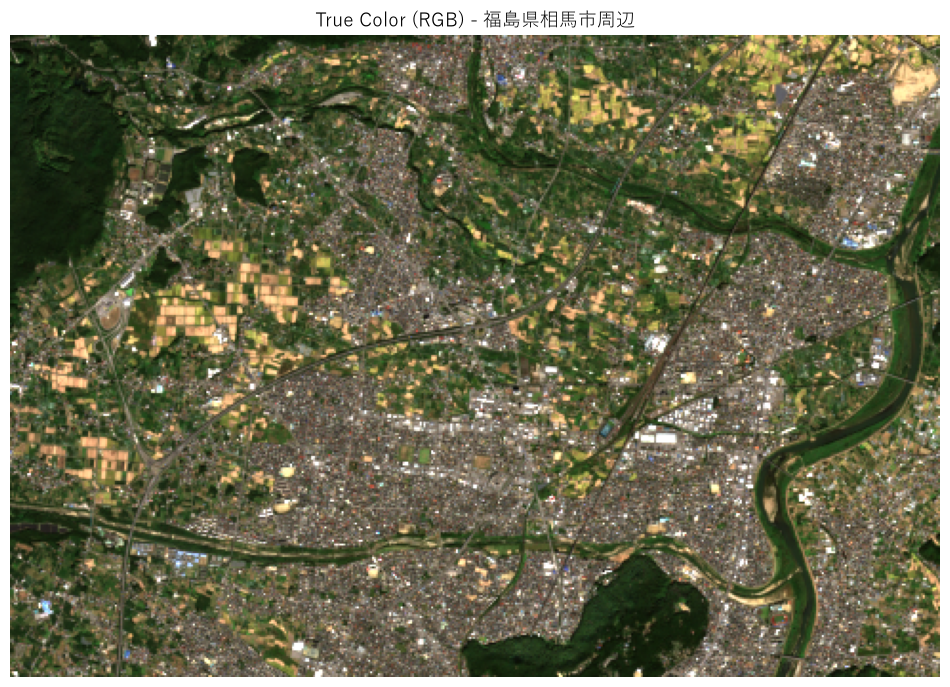

In [9]:
# EETODO: RGB 表示に使うバンド名を指定せよ
vis_rgb = {
    'bands': ['B4', 'B3', 'B2'],  # 正しい3つのバンド名
    'min': 0,
    'max': 2000
}

print('RGB画像を取得中...')
rgb_arr = geemap.ee_to_numpy(image, region=DISPLAY_ROI,
                              bands=vis_rgb['bands'], scale=20)
# EETODO: 適切な値でスケーリングせよ（反射率 ×10000 の値を 0〜1 に収める）
rgb_display = np.clip(rgb_arr / 2000, 0, 1)

plt.figure(figsize=(12, 10))
plt.imshow(rgb_display)
plt.title('True Color (RGB) - 福島県相馬市周辺', fontsize=14)
plt.axis('off')
plt.show()

# 考察（必須）:
# Q1. Sentinel-2の反射率はなぜ整数値で格納されているのか？
#     （例：反射率0.3が値3000で格納されている理由）
#     浮動小数点で直接格納しない理由を推測せよ。
# Q2. 表示された画像で、農地・森林・水域・市街地はそれぞれ
#     どの色に見えるか？それはスペクトルカーブのどの特性から説明できるか？
# → ここに考察を書く


> **ヒント STEP 2**
>
> - True Color は Red・Green・Blue の3バンド。Sentinel-2 のバンド名は B1〜B12
> - Red=B4, Green=B3, Blue=B2
> - Sentinel-2 の反射率は **10000 倍** の整数値で格納されている（例: 反射率0.3 → 値3000）
> - 3000 で割ると反射率0.3、つまり緑色の植生が白飛びしない値として適切

---
## STEP 3: NDVI を計算する

NDVI = (NIR - Red) / (NIR + Red) です。
この式をコードで表現してください。
**ヒント:** Sentinel-2 の NIR は B8、Red は B4 です。

NDVI 範囲: {'NDVI_max': 0.9442786069651742, 'NDVI_min': -0.7164556962025317}
NDVI画像を取得中...


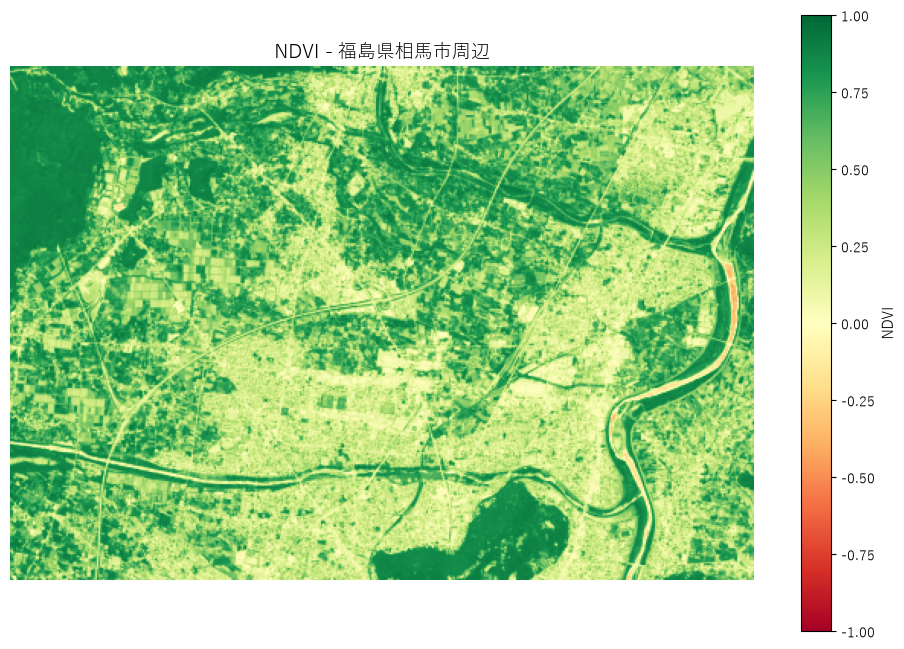

In [50]:
# EETODO: NDVI を計算せよ。適切なバンド名を指定すること
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

# NDVI の統計情報
stats = ndvi.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=ROI,
    scale=100,
    bestEffort=True
)
print(f'NDVI 範囲: {stats.getInfo()}')

print('NDVI画像を取得中...')
ndvi_arr = geemap.ee_to_numpy(ndvi, region=DISPLAY_ROI,
                              bands=['NDVI'], scale=20)

plt.figure(figsize=(12, 10))
plt.imshow(ndvi_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI', shrink=0.8)
plt.title('NDVI - 福島県相馬市周辺', fontsize=14)
plt.axis('off')
plt.show()

# 考察（必須）:
# Q1. 計算されたNDVIの最大値・最小値を確認し、
#     「この値が物理的に正しい範囲か」を判断せよ。
#     （例：NDVI > 1.0が出た場合は何かがおかしい）
# Q2. NDVIマップを見て、高い値（緑色）のエリアと
#     低い値（赤色）のエリアを1箇所ずつ特定せよ。
#     Copernicus Browserで同日付の画像を開いて
#     実際に何が写っているか確認し、値と地物が一致しているか検証せよ。
# → ここに考察を書く
# NDVIは-1から1の間の値に収まっているので妥当と思われる。



In [51]:
# ── AI検証（任意・Exercise Log ②に記録）──
# 以下のプロンプトをChatGPTまたはGeminiに投げてコードを生成させよ。
# 「Google Earth EngineのPython APIを使って、
#  Sentinel-2画像からNDVIを計算するコードを書いてください」
#
# 生成されたコードを見て以下を確認せよ：
# □ バンドの指定方法が自分のコードと一致しているか
# □ normalizedDifference の引数順（[NIR, Red]か[Red, NIR]か）
# □ 生成されたコードに ee.ImageCollection の初期化が含まれているか
#
# 不一致があった場合：どちらが正しいか、物理的根拠から説明せよ。
# （「AIがそう言ったから」ではなく、スペクトルカーブに基づいて判断すること）


> **ヒント STEP 3（改訂版）**
>
> - NDVI計算に必要な2つのバンドは「植生が赤色光を吸収する帯域」と
>   「植生の葉肉構造が強く反射する帯域」である
> - Sentinel-2 のバンド一覧（B1〜B12）と中心波長は
>   Copernicus BrowserのSentinel-2カタログで確認できる
> - どのバンドがそれぞれに対応するかを自分で判断してから埋めること
> - それでもわからなければ答えを _private/01_kogaku.ipynb で確認してよい


---
## STEP 4: スペクトルプロファイルを確認する

実際の画像から、地物ごとの分光反射率をプロットします。
下のコードはほぼ完成していますが、**新しい地物タイプを1つ追加** してみましょう。

森林 (Forest): B4(Red)=0.070, B8(NIR)=0.201
水域 (Water): B4(Red)=0.029, B8(NIR)=0.005
裸地 (Bare): B4(Red)=0.122, B8(NIR)=0.265
都市 (Urban): B4(Red)=0.156, B8(NIR)=0.177
農地 (Farm): B4(Red)=0.059, B8(NIR)=0.297


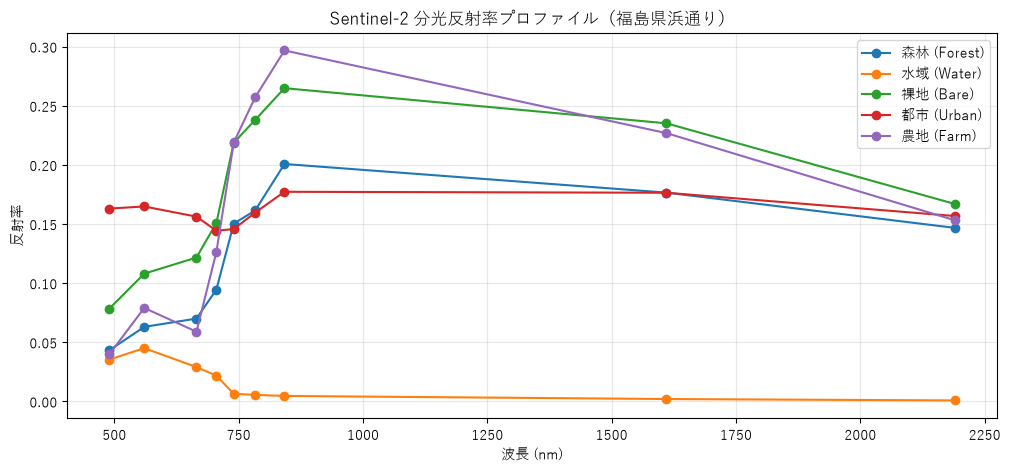

In [52]:
# 各地物タイプの代表点
points = {
    '森林 (Forest)': FOREST_PT,
    '水域 (Water)': WATER_PT,
    '裸地 (Bare)': BARE_PT,
    # Copernicus Browser で確認した座標を入力すること
    '都市 (Urban)': URBAN_PT,
    '農地 (Farm)': FARM_POINT,
    # EETODO: 興味のある地物を1つ追加せよ
    # '???': ee.Geometry.Point([???, ???]),
}

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12']
band_centers = [490, 560, 665, 705, 740, 783, 842, 1610, 2190]

spectra = {}
for name, pt in points.items():
    values = image.select(bands).reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=pt.buffer(50),
        scale=10
    ).getInfo()
    if values is None:
        print(f'{name}: データなし')
        continue
    refl = []
    for b in bands:
        val = values.get(b, None)
        if val is not None:
            refl.append(val / 10000)
        else:
            refl.append(None)
    spectra[name] = refl
    print(f'{name}: B4(Red)={refl[2]:.3f}, B8(NIR)={refl[6]:.3f}')

plt.figure(figsize=(12, 5))
for name, refl in spectra.items():
    if refl:
        plt.plot(band_centers, refl, marker='o', label=name)
plt.xlabel('波長 (nm)')
plt.ylabel('反射率')
plt.title('Sentinel-2 分光反射率プロファイル（福島県浜通り）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 考察（必須）:
# Q1. 農地（作付け中）と収穫後農地のスペクトルを比べて、
#     NIRバンド（B8、波長842nm）付近でどのような違いがあるか？
#     その違いは「葉の構造と散乱」の観点からどう説明できるか？
# Q2. 収穫後農地と裸地のスペクトルが似ている場合、
#     光学センサだけでこれらを区別するのは難しい。
#     その理由を物理的根拠から説明せよ。
# → ここに考察を書く


---
## STEP 5: 光学センサの限界（雲）を体験する

雲の多い画像をあえて選び、NDVI がどのように影響を受けるか確認します。

雲80%以上の画像数: 6
選択画像: 20240602T011659_20240602T011653_T54SVG
雲被覆率: 87.84821%
雲あり画像を取得中...


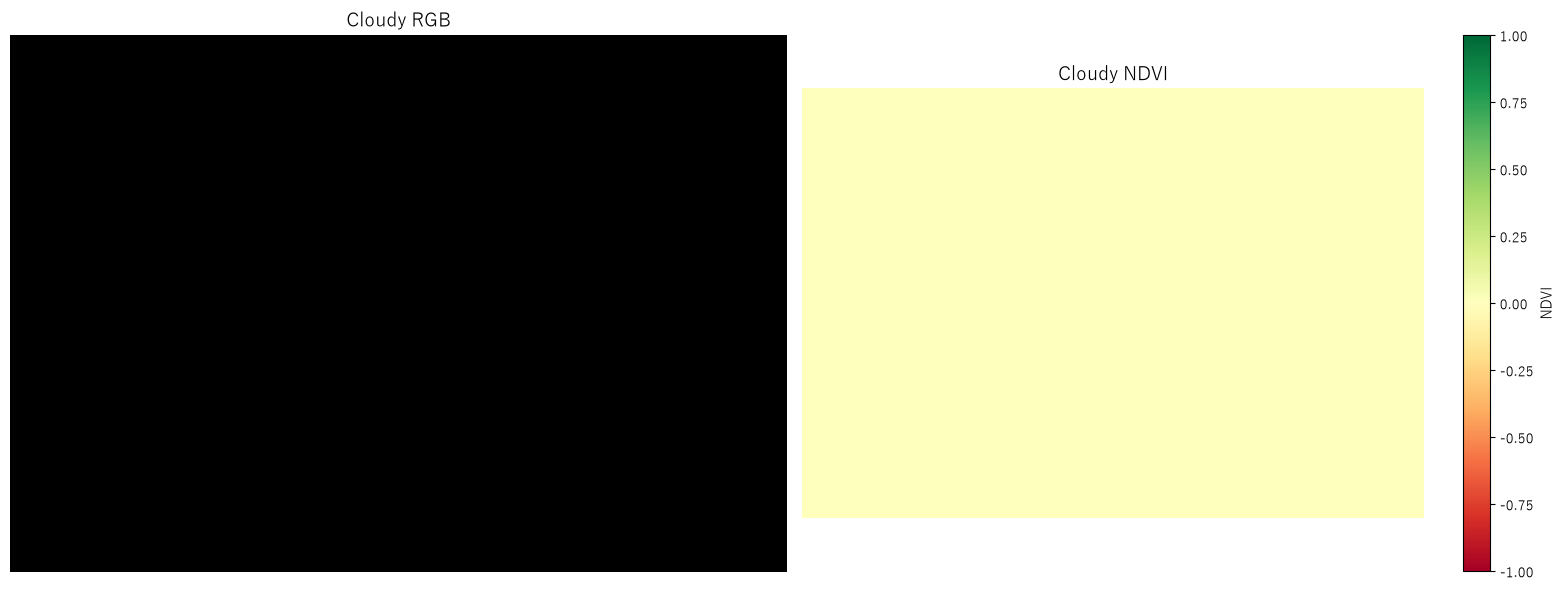

In [55]:
# EETODO: 雲80%以上の画像を取得せよ
cloudy_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2024-06-01', '2024-06-30')
    .filterBounds(ROI)
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'greater_than', 80)
)

print(f'雲80%以上の画像数: {cloudy_collection.size().getInfo()}')

if cloudy_collection.size().getInfo() > 0:
    cloudy_image = cloudy_collection.first()
    print(f'選択画像: {cloudy_image.id().getInfo()}')
    print(f'雲被覆率: {cloudy_image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo()}%')

    ndvi_cloudy = cloudy_image.normalizedDifference(['B8', 'B4']).rename('NDVI_cloudy')

    print('雲あり画像を取得中...')
    rgb_cloudy = geemap.ee_to_numpy(cloudy_image, region=DISPLAY_ROI,
                                     bands=['B4', 'B3', 'B2'], scale=20)
    ndvi_cloudy_arr = geemap.ee_to_numpy(ndvi_cloudy, region=DISPLAY_ROI,
                                         bands=['NDVI_cloudy'], scale=20)
    rgb_cloudy_disp = np.clip(rgb_cloudy / 3000, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(rgb_cloudy_disp)
    axes[0].set_title('Cloudy RGB', fontsize=14)
    axes[0].axis('off')
    im = axes[1].imshow(ndvi_cloudy_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1].set_title('Cloudy NDVI', fontsize=14)
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], shrink=0.8, label='NDVI')
    plt.tight_layout()
    plt.show()
else:
    print('6月に雲80%以上の画像が見つかりませんでした。')
    print('以下のいずれかを試してみましょう：')
    print('1. 期間を梅雨の時期（2024-06-01〜2024-08-31）に広げる')
    print('2. 閾値を70%以上に下げる')
    print('3. 元の collection から最も雲が多い画像を逆順ソートで取得する')
    print('→ どの方法を試したか、なぜそれを選んだかをExercise Logに記録すること')


> **ヒント STEP 5**
>
> - `filterMetadata` の第一引数は `'CLOUDY_PIXEL_PERCENTAGE'`
> - 比較演算子には `'greater_than'` を使う
> - 閾値は 80（%）

---
## ⭐ チャレンジ課題（発展・任意）

**最低2問以上** に挑戦し、結果を Exercise Log に記録しよう。
各課題の「自力で調べる度合い」が異なるので、自分に合った難易度を選んでよい。

| # | 課題 | 難易度 | 本タスクとの関係 |
|---|------|--------|----------------|
| C1 | 複数時期の NDVI 比較 | ★★☆ | 時系列の基本。「NDVI ピークの有無」が休耕判定の第一歩 |
| C2 | SCL を使った雲・影マスキング | ★★☆ | 時系列解析にはピクセル単位の雲除去が必須 |
| C3 | NDVI 時系列グラフ（年間） | ★☆☆ | 作物の生育サイクル全体を把握する（コードはほぼ完成） |
| C4 | NDVI 閾値分類による簡易土地被覆図 | ★☆☆ | 面的な植生分布を定量評価（考察がメイン） |
| C5 | 農地区画の NDVI 統計取得 | ★★★ | 実際の農地ポリゴン解析の予行演習（応用問題） |

---
### ⭐ C1: 複数時期の NDVI 比較

**問題:** 春・夏・秋の NDVI を計算し、作付けの有無を比較せよ。

**埋める箇所:**
- `periods` の期間は適切か？各自で調整してもよい
- `normalizedDifference` のバンド名指定
- `ee_to_numpy` の `bands` 引数（ndvi 画像のバンド名と一致させること）

In [ ]:
# 3 つの異なる時期の画像を取得
periods = [
    ('2024-04-01', '2024-04-30', 'Spring', '春'),
    ('2024-07-01', '2024-07-31', 'Summer', '夏'),
    ('2024-10-01', '2024-10-31', 'Autumn', '秋'),
]

images = []
for start, end, eng, jp in periods:
    label = f'{jp} ({eng})'
    col = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start, end)
        .filterBounds(DISPLAY_ROI)
        .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 30)
    )
    count = col.size().getInfo()
    if count == 0:
        print(f'{label}: 該当画像なし')
        continue
    img = col.sort('CLOUDY_PIXEL_PERCENTAGE').first()
    # EETODO: NDVI を計算せよ。バンド名を適切に指定すること
    ndvi_img = img.normalizedDifference([???, ???]).rename(f'NDVI_{eng}')
    images.append((label, ndvi_img, f'NDVI_{eng}'))
    print(f'{label}: 撮影日 {img.date().format("YYYY-MM-dd").getInfo()}')

# 3 時期の NDVI を並べて表示
if len(images) >= 2:
    print('各時期の NDVI を取得中...')
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    im = None
    for ax, (label, ndvi_img, band_name) in zip(axes, images):
        # EETODO: 適切な band 名を指定せよ
        arr = geemap.ee_to_numpy(ndvi_img, region=DISPLAY_ROI,
                                 bands=[???], scale=20)
        im = ax.imshow(arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
        ax.set_title(f'NDVI {label}', fontsize=12)
        ax.axis('off')
    fig.colorbar(im, ax=axes, orientation='horizontal', shrink=0.6,
                 pad=0.05, label='NDVI')
    plt.tight_layout()
    plt.show()
else:
    print('比較できる画像が不足しています。期間を調整して再実行してみよう。')

# 考察（必須）:
# Q1. 春・夏・秋のNDVIを比べて、最も高い時期はいつか？
#     これは水稲の生育カレンダーと一致しているか確認せよ。
# Q2. 秋（収穫後）のNDVIと春（移植前）のNDVIが似た値になる場合がある。
#     この2つを「休耕地」と間違えないためには何が必要か？
#     「多時期データのどのパターンを見れば休耕地と区別できるか」を説明せよ。
# → ここに考察を書く


---
### ⭐ C2: SCL を使った雲・影マスキング

**問題:** SCL（Scene Classification Layer）を使って雲と影のピクセルを除去し、
マスク前後の NDVI を比較せよ。

**埋める箇所:** コレクションからの画像取得、NDVI計算、ee_to_numpy

In [ ]:
# 雲と影のマスク関数
# Sentinel-2 SCL（Scene Classification Layer）のクラス番号:
# 1: 飽和・欠落  2: 暗い植生  3: 雲の影  4: 植生  5: 裸地
# 6: 水  7: 低い確率の雲  8: 中程度の確率の雲  9: 高い確率の雲
# 10: 薄い雲（巻雲）  11: 雪・氷
# → 除去したいクラス番号はどれか？関数のコードと照合せよ

def mask_clouds_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.updateMask(
        scl.neq(3).And(scl.neq(7).And(scl.neq(8).And(scl.neq(9))))
    )
    return image.updateMask(cloud_mask)

# EETODO: collection から最も雲の少ない画像を1枚取得せよ
normal_image = ???
masked_image = mask_clouds_scl(normal_image)

# EETODO: NDVI を計算せよ（マスクなし / マスク済み の2つ）
ndvi_normal = normal_image.normalizedDifference([???, ???]).rename('NDVI_normal')
ndvi_masked = masked_image.normalizedDifference([???, ???]).rename('NDVI_masked')

print('雲マスク比較画像を取得中...')
ndvi_norm_arr = geemap.ee_to_numpy(ndvi_normal, region=DISPLAY_ROI,
                                   bands=['NDVI_normal'], scale=20)
ndvi_mask_arr = geemap.ee_to_numpy(ndvi_masked, region=DISPLAY_ROI,
                                   bands=['NDVI_masked'], scale=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(ndvi_norm_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI（マスクなし）', fontsize=14)
axes[0].axis('off')
im1 = axes[1].imshow(ndvi_mask_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title('NDVI（雲マスク済み）', fontsize=14)
axes[1].axis('off')
fig.colorbar(im1, ax=axes, orientation='horizontal', shrink=0.6,
             pad=0.05, label='NDVI')
plt.tight_layout()
plt.show()

# 考察: マスク前後でどこが変化したか。光学センサで雲が問題になる理由を説明せよ
# Q2. 雲マスクを適用したことで、NDVIの値は改善されたか？
# Q3. SCLを使った自動マスクの限界はどこにあるか？
#     （過剰除去・除去不足が発生しうる状況を考えよ）
# → ここに考察を書く
# → ここに考察を書く

---
### ⭐ C3: NDVI 時系列グラフ（年間）

**問題:** 農地上の1点について、1年を通した NDVI の変化をプロットせよ。

**この課題はコードがほぼ完成しています。** 以下の点を理解しながら実行すること：
- なぜ `filterMetadata` の閾値を60%にしているか？
- `copyProperties` はなぜ必要か？
- グラフのピーク時期から何が読み取れるか？

In [ ]:
# 農地上の 1 点を選ぶ

# 2024 年 1 月〜12 月の全画像を取得
ts_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2024-01-01', '2024-12-31')
    .filterBounds(FARM_POINT)
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 60)
    .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI')
               .copyProperties(img, ['system:time_start']))
)

def extract_ndvi(image):
    nd = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=FARM_POINT,
        scale=10
    ).get('NDVI')
    date = image.date().format('YYYY-MM-dd')
    return ee.Feature(None, {'date': date, 'NDVI': nd})

try:
    features = ts_collection.map(extract_ndvi).getInfo()['features']
    dates, values = [], []
    for f in features:
        props = f['properties']
        if props.get('NDVI') is not None:
            dates.append(props['date'])
            values.append(props['NDVI'])

    if len(dates) > 0:
        plt.figure(figsize=(12, 4))
        plt.plot(dates, values, marker='o', linestyle='-', markersize=3)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('NDVI')
        plt.title('農地 1 点の NDVI 時系列（2024年）')
        plt.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5,
                    label='植生の目安 (NDVI=0.3)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f'データ点数: {len(dates)}')
        print(f'NDVI 最大: {max(values):.3f}, 最小: {min(values):.3f}')
    else:
        print('有効なデータがありません。')
except Exception as e:
    print(f'エラー: {e}')

# 考察（必須）:
# Q1. NDVI のピークはいつか？
# Q2. 雲の影響でデータが欠損している時期はあるか？
# Q3. NDVIが突然0に近い値になっている時期があれば、
#     それは「収穫後」「雲の影響」「センサの異常」のどれが原因か、
#     撮影日と季節から推定せよ。
# Q4. このグラフの農地が「休耕地」だった場合、
#     グラフの形はどう変わるはずか？説明せよ。
#     （休耕地は草地化するため植生はゼロではないが、
#      水稲特有のピークパターンが現れない）
# → ここに考察を書く


---
### ⭐ C4: NDVI 閾値分類による簡易土地被覆図

**問題:** NDVI の値に応じて土地を3クラスに分類し、面積割合を計算せよ。

**この課題はコードがほぼ完成しています。** 以下の考察に答えることが主目的。

In [ ]:
# NDVI の値に応じて 3 クラスに分類
# ★ EETODO: 閾値を自分で設定せよ（STEP 4のスペクトルカーブを参照）

THRESHOLD_WATER = ???   # 水域と裸地の境界（スペクトルカーブから推定）
THRESHOLD_VEG   = ???   # 裸地と植生の境界（スペクトルカーブから推定）

water = ndvi.lt(THRESHOLD_WATER).rename('water')
bare = ndvi.gte(THRESHOLD_WATER).And(ndvi.lte(THRESHOLD_VEG)).rename('bare')
veg = ndvi.gt(THRESHOLD_VEG).rename('veg')

classified = water.multiply(1).add(bare.multiply(2)).add(veg.multiply(3)).rename('classified')

area_stats = classified.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=ROI,
    scale=100,
    bestEffort=True
).getInfo()

print('=== 土地被覆分類のピクセル数 ===')
class_names = {1: '水域 (Water)', 2: '裸地 (Bare)', 3: '植生 (Vegetation)'}
total = sum(area_stats['classified'].values())
for k, v in sorted(area_stats['classified'].items()):
    name = class_names.get(int(k), f'クラス{k}')
    print(f'{name}: {v} ピクセル ({v/total*100:.1f}%)')

print('分類画像を取得中...')
class_arr = geemap.ee_to_numpy(classified, region=DISPLAY_ROI,
                               bands=['classified'], scale=20)
class_arr_2d = class_arr.squeeze()

cmap_class = plt.matplotlib.colors.ListedColormap(['blue', 'brown', 'green'])
plt.figure(figsize=(12, 10))
plt.imshow(class_arr_2d, cmap=cmap_class, vmin=1, vmax=3)
cbar = plt.colorbar(ticks=[1, 2, 3], shrink=0.8)
cbar.ax.set_yticklabels(['水域', '裸地', '植生'])
plt.title('土地被覆分類', fontsize=14)
plt.axis('off')
plt.show()

# 考察:
# Q1. この地域で最も面積が大きいクラスは何か？その理由を地理的に考察せよ
# Q2. 閾値を変えると結果はどう変わるか？試してみよ
# → ここに考察を書く

---
### ⭐ C5: 農地区画の NDVI 統計取得（応用）

**問題:** 事前に定義した農地区画（長方形）の NDVI 統計値を計算せよ。

**チャレンジ（自力で考える要素が多い）:**
- `reduceRegion` の reducer を自分で調べて書く
- `ee_to_numpy` の前に、ndviが計算済みであることを確認する

In [ ]:
# 事前に定義した農地区画
# EETODO: reduceRegion を使って FARM_PLOT 内の NDVI 統計を計算せよ
# ヒント: reducer には ee.Reducer.mean() / stdDev() / minMax() などがある
# 複数の reducer を combine() で連結できる
ndvi_stats = ndvi.reduceRegion(
    reducer=???,  # 平均・標準偏差・最小最大 を結合した reducer を作れ
    geometry=FARM_PLOT,
    scale=10,
    bestEffort=True
).getInfo()

print('=== 選択範囲の NDVI 統計 ===')
for k, v in ndvi_stats.items():
    val_str = f'{v:.3f}' if v is not None else 'N/A'
    print(f'{k}: {val_str}')

# EETODO: 平均 NDVI の値に基づいて植生状態を自動判定せよ
# ★ C4で設定した閾値を使うか、
# 「農地」という特定の地物を対象にする場合の別の閾値を判断せよ。
# 判断の根拠をコメントとして書くこと。
mean_ndvi = ndvi_stats.get('NDVI_mean', 0)
if mean_ndvi > ???:  # C4 の THRESHOLD_VEG を参照
    print('▶ 判定: 植生あり（作付け中 or 自然植生）')
elif mean_ndvi > ???:  # C4 の THRESHOLD_WATER を参照
    print('▶ 判定: 裸地 or 低植生（収穫後・休耕の可能性）')
else:
    print('▶ 判定: 水域')

# 対象領域を RGB 画像で確認
print('解析対象領域を RGB 画像で確認中...')
rgb_arr = geemap.ee_to_numpy(image, region=DISPLAY_ROI,
                              bands=['B4', 'B3', 'B2'], scale=20)
rgb_display = np.clip(rgb_arr / 3000, 0, 1)
plt.figure(figsize=(12, 10))
plt.imshow(rgb_display)
plt.title('解析対象の農地区画\n(経度 140.90-140.93, 緯度 37.64-37.67)', fontsize=14)
plt.axis('off')
plt.show()

---
## まとめ

### 今日学んだこと
- Sentinel-2 画像を GEE で検索・取得する方法
- NDVI の計算と可視化
- 地物ごとの分光反射率プロファイル
- 光学センサの限界（雲の影響）
- チャレンジ課題を通じた応用力

### 提出内容（スライドの宿題に従う）

**① 必須：以下の2点を自分の言葉で説明**
- Q1. 7月（生育期）と10月（収穫後）のNDVI値はどう変わるか？
- Q2. 収穫後の農地と休耕地を光学だけで区別しようとすると、なぜ失敗するのか？

**② AIを使った場合のみ：AIに同じNDVIコードを書かせ、B4（Red）・B8（NIR）のバンドインデックス指定が一致するか確認し差異を記録**

**⭐ 発展課題（いずれか1つ以上）：**
- (a) NDVI値域が-1〜1に収まっているか確認し、外れていたら原因を推測
- (b) EVIの式を調べ、NDVIと何が違うかを物理的根拠から説明
